# RDKit vs Chematic 2D layout

Side-by-side depiction comparison for the same SMILES. No xpict — just each library’s own drawer so we can judge **coordinate / layout quality**.

- **RDKit**: CoordGen preferred (`rdDepictor.SetPreferCoordGen(True)`), then `MolDraw2DSVG`
- **Chematic**: `mol.svg()` / `depict_data()` (pure-Rust layout)

Also plots a Procrustes overlay of atom coords (geometry only, ignoring drawing style). Reflection is allowed — mirrored drawings of the same layout score as matches.

```bash
# from repo root, if needed:
uv pip install --python .venv/bin/python chematic matplotlib
.venv/bin/python -m ipykernel install --user --name xpict --display-name "Python (xpict)"
```

In [1]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass

import chematic
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, SVG, display
from rdkit import Chem
from rdkit.Chem import AllChem, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

rdDepictor.SetPreferCoordGen(True)

print("chematic", getattr(chematic, "__version__", "?"))
print("rdkit", Chem.rdBase.rdkitVersion)

chematic 1.0.28
rdkit 2026.03.6


In [2]:
@dataclass(frozen=True)
class Case:
    id: str
    smiles: str
    notes: str = ""


# Easy / gallery-ish cases from xpict hard-case list
CASES: list[Case] = [
    Case("benzene", "c1ccccc1", "aromatic hexagon"),
    Case("phenol", "c1ccccc1O", "hetero label"),
    Case("aspirin", "CC(=O)Oc1ccccc1C(=O)O", "ortho + carbonyls"),
    Case("indole", "c1ccc2[nH]ccc2c1", "fused 6+5"),
    Case("naphthalene", "c1ccc2ccccc2c1", "fused aromatics"),
    Case("biphenyl", "c1ccc(-c2ccccc2)cc1", "linked rings"),
    Case("acetone", "CC(=O)C", "acyclic carbonyl"),
    Case("pyridine", "c1ccncc1", "hetero aromatic"),
    Case("nitrobenzene", "c1ccc(cc1)[N+](=O)[O-]", "charges"),
    Case("caffeine", "Cn1cnc2c1c(=O)n(c(=O)n2C)C", "fused hetero + carbonyls"),
    # Bridged / cage — layout stress tests
    Case("norbornane", "C1CC2CCC1C2", "bridged"),
    Case("cubane", "C12C3C4C1C5C2C3C45", "cage"),
    Case("adamantane", "C1C2CC3CC1CC(C2)C3", "cage"),
    Case("barrelene", "C1=CC2C=CC1C=C2", "bridged unsaturated"),
    # Stereo / crowding
    Case("alanine", "C[C@H](N)C(=O)O", "tetrahedral stereo"),
    Case(
        "cholesterol",
        "C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3[C@H]2CC=C4[C@@]3(CC[C@@H](C4)O)C)C",
        "steroid",
    ),
    Case(
        "morphine",
        "CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)O)O[C@H]3[C@H](C=C4)O",
        "polycyclic alkaloid",
    ),
    Case(
        "penicillin_g",
        "CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O",
        "beta-lactam + stereo",
    ),
    Case("long_chain", "CCCCCCCCCCCCCCCC(=O)O", "long aliphatic"),
    Case("macrocycle", "O=C1CCCCCCCCCCC(=O)O1", "macrocycle"),
]

In [3]:
def rdkit_svg(smiles: str, size: tuple[int, int] = (280, 220)) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit parse failed: {smiles}")
    rdDepictor.Compute2DCoords(mol)
    d = rdMolDraw2D.MolDraw2DSVG(*size)
    d.drawOptions().clearBackground = True
    d.drawOptions().addStereoAnnotation = True
    rdMolDraw2D.PrepareAndDrawMolecule(d, mol)
    d.FinishDrawing()
    return d.GetDrawingText()


def chematic_svg(smiles: str) -> str:
    mol = chematic.from_smiles(smiles)
    return mol.svg()


def rdkit_coords(smiles: str) -> np.ndarray:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit parse failed: {smiles}")
    rdDepictor.Compute2DCoords(mol)
    conf = mol.GetConformer()
    return np.array(
        [
            [conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y]
            for i in range(mol.GetNumAtoms())
        ]
    )


def chematic_coords(smiles: str) -> np.ndarray:
    data = chematic.from_smiles(smiles).depict_data()
    # depict_data atom order should match SMILES atom order for both libs;
    # if counts differ we still plot what we get.
    atoms = sorted(data["atoms"], key=lambda a: a["idx"])
    return np.array([[a["x"], a["y"]] for a in atoms], dtype=float)


def procrustes_overlay(
    a: np.ndarray, b: np.ndarray, *, allow_reflection: bool = True
) -> tuple[np.ndarray, np.ndarray, float]:
    """Align b onto a (uniform scale + rigid; reflection allowed by default).

    Chem drawings are often mirrors of each other; forcing det(R)>0 makes
    identical hexagons look totally wrong. Returns (a_centered, b_aligned, rmsd)
    in RDKit length units.
    """
    if len(a) != len(b) or len(a) < 2:
        raise ValueError(f"coord length mismatch: {len(a)} vs {len(b)}")
    a = a - a.mean(axis=0)
    b = b - b.mean(axis=0)
    H = b.T @ a
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if not allow_reflection and np.linalg.det(R) < 0:
        Vt = Vt.copy()
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
    b_rot = b @ R
    denom = float(np.sum(b_rot * b_rot))
    scale = float(np.sum(a * b_rot) / denom) if denom > 1e-12 else 1.0
    b_al = b_rot * scale
    rmsd = float(np.sqrt(np.mean(np.sum((a - b_al) ** 2, axis=1))))
    return a, b_al, rmsd


def side_by_side(case: Case, width: int = 280) -> HTML:
    try:
        r_svg = rdkit_svg(case.smiles, size=(width, int(width * 0.8)))
        r_err = None
    except Exception as e:
        r_svg, r_err = None, str(e)
    try:
        c_svg = chematic_svg(case.smiles)
        c_err = None
    except Exception as e:
        c_svg, c_err = None, str(e)

    def cell(title: str, svg: str | None, err: str | None) -> str:
        body = err if err else (svg or "")
        # strip xml decl from RDKit for HTML embed
        body = re.sub(r"^<\?xml[^>]*\?>", "", body).strip()
        return (
            f'<div style="flex:1;min-width:240px;border:1px solid #ddd;padding:8px;margin:4px">'
            f"<div style='font:600 13px sans-serif;margin-bottom:6px'>{title}</div>"
            f"{body}</div>"
        )

    html = (
        f"<div style='margin:16px 0 28px'"
        f"><div style='font:700 15px sans-serif'>{case.id}</div>"
        f"<div style='font:12px monospace;color:#444;margin:2px 0 8px;word-break:break-all'>{case.smiles}</div>"
        f"<div style='font:12px sans-serif;color:#666;margin-bottom:6px'>{case.notes}</div>"
        f"<div style='display:flex;flex-wrap:wrap'>"
        f"{cell('RDKit (CoordGen)', r_svg, r_err)}"
        f"{cell('Chematic', c_svg, c_err)}"
        f"</div></div>"
    )
    return HTML(html)

## Gallery — native SVG from each library

In [4]:
for case in CASES:
    display(side_by_side(case))

## Coordinate overlay (Procrustes)

Blue = RDKit atoms after centering. Orange = Chematic atoms rigid-aligned + scaled onto RDKit. RMSD is in RDKit layout units after alignment — useful for relative ranking across molecules, not absolute Å.

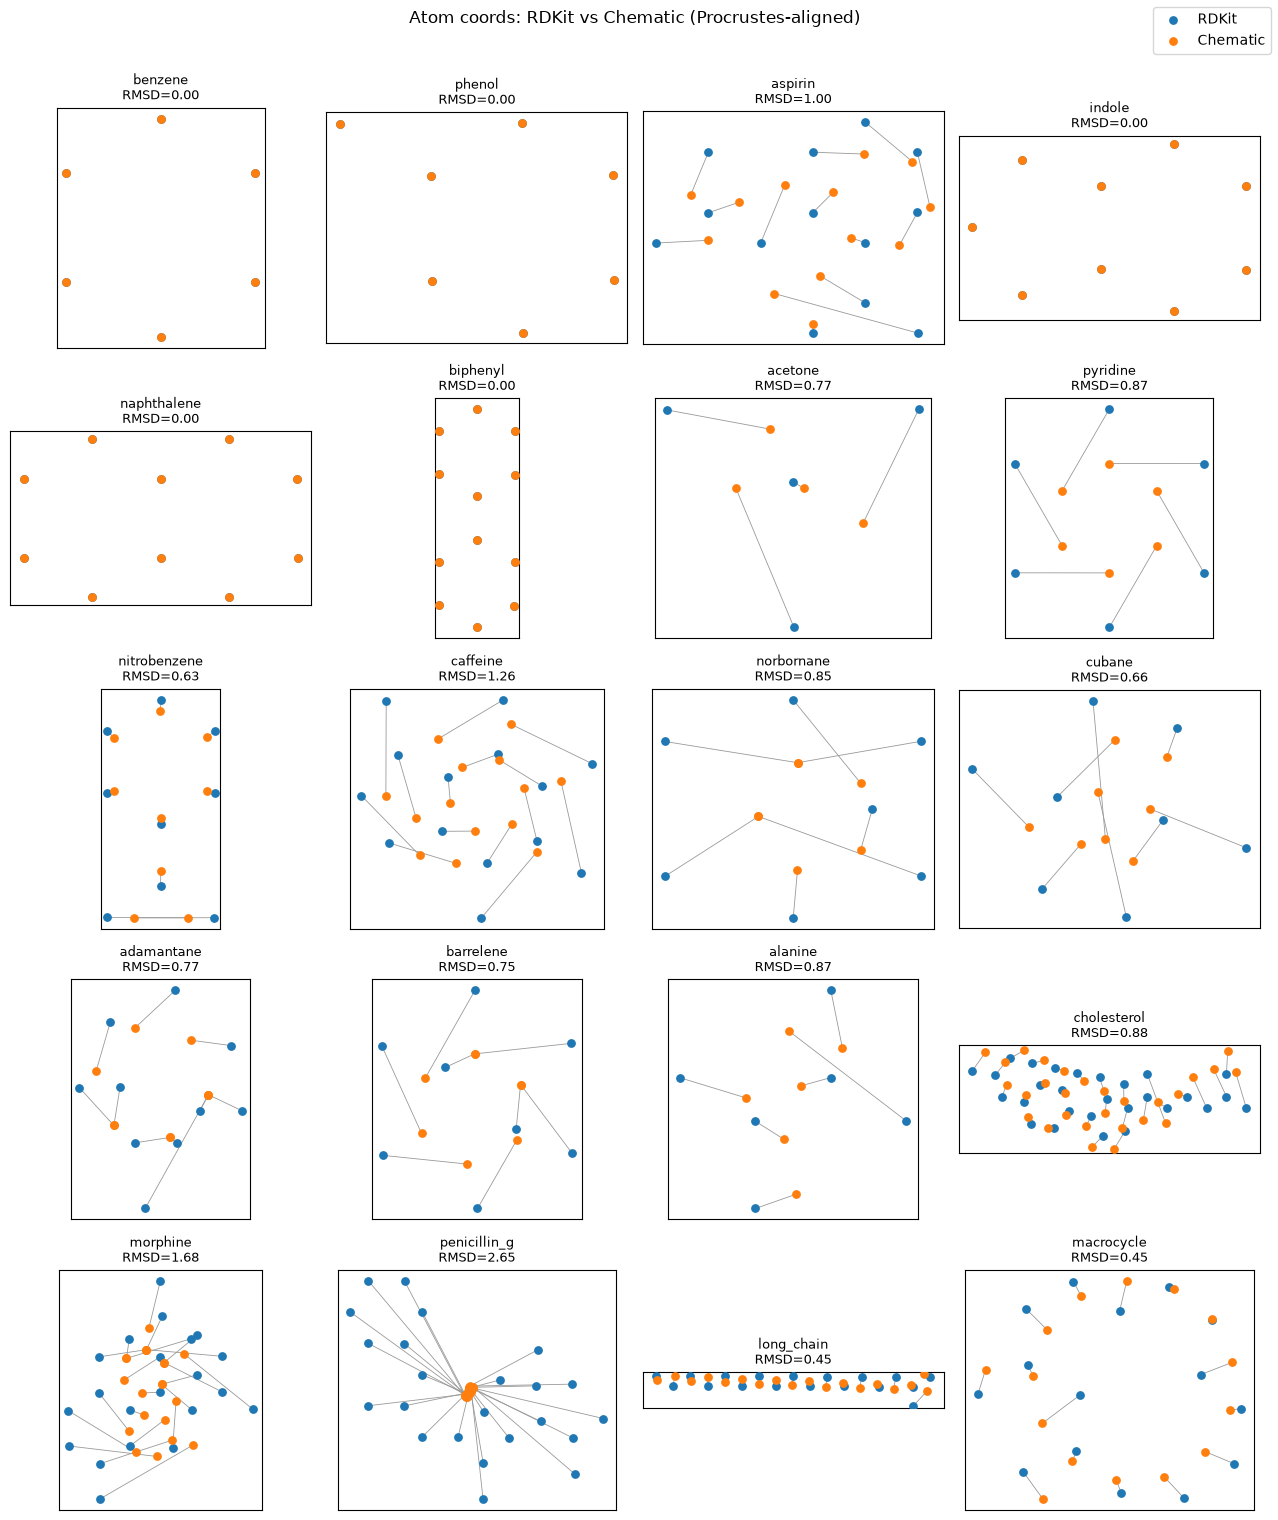

Worst → best Procrustes RMSD (higher = more different geometry):
    2.651  penicillin_g
    1.679  morphine
    1.259  caffeine
    0.996  aspirin
    0.876  cholesterol
    0.865  alanine
    0.865  pyridine
    0.850  norbornane
    0.771  adamantane
    0.769  acetone
    0.749  barrelene
    0.659  cubane
    0.628  nitrobenzene
    0.455  long_chain
    0.451  macrocycle
    0.000  indole
    0.000  naphthalene
    0.000  biphenyl
    0.000  benzene
    0.000  phenol


In [5]:
rows: list[tuple[Case, float | None, str | None]] = []

n = len(CASES)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, case in zip(axes, CASES):
    err = None
    rmsd = None
    try:
        a = rdkit_coords(case.smiles)
        b = chematic_coords(case.smiles)
        if len(a) != len(b):
            raise ValueError(f"atom count {len(a)} vs {len(b)}")
        a_c, b_al, rmsd = procrustes_overlay(a, b)
        ax.scatter(a_c[:, 0], a_c[:, 1], s=28, c="#1f77b4", label="RDKit", zorder=3)
        ax.scatter(
            b_al[:, 0], b_al[:, 1], s=28, c="#ff7f0e", label="Chematic", zorder=3
        )
        for i in range(len(a_c)):
            ax.plot(
                [a_c[i, 0], b_al[i, 0]],
                [a_c[i, 1], b_al[i, 1]],
                color="#999",
                lw=0.6,
                zorder=2,
            )
        ax.set_title(f"{case.id}\nRMSD={rmsd:.2f}", fontsize=9)
    except Exception as e:
        err = str(e)
        ax.set_title(f"{case.id}\nFAIL", fontsize=9, color="crimson")
        ax.text(
            0.5,
            0.5,
            err,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=7,
            wrap=True,
        )
    ax.set_aspect("equal")
    ax.invert_yaxis()  # chem drawing convention
    ax.set_xticks([])
    ax.set_yticks([])
    rows.append((case, rmsd, err))

for ax in axes[len(CASES) :]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right")
fig.suptitle("Atom coords: RDKit vs Chematic (Procrustes-aligned)", y=1.01)
fig.tight_layout()
plt.show()

ok = [(c.id, r) for c, r, e in rows if r is not None]
ok.sort(key=lambda t: t[1], reverse=True)
print("Worst → best Procrustes RMSD (higher = more different geometry):")
for cid, r in ok:
    print(f"  {r:7.3f}  {cid}")
fails = [c.id for c, r, e in rows if e]
if fails:
    print("Failures:", fails)

## Single-molecule deep dive

Change `FOCUS` to inspect one structure more closely.

atoms RDKit=21 Chematic=21


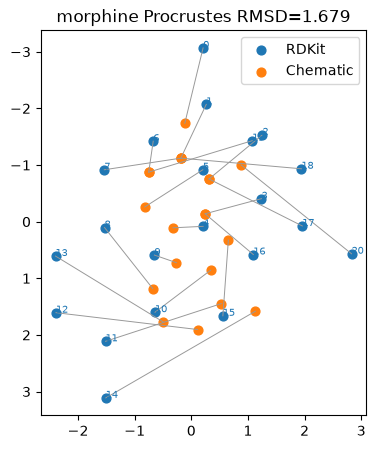

In [6]:
FOCUS = "morphine"  # case id from CASES

case = next(c for c in CASES if c.id == FOCUS)
display(side_by_side(case, width=360))

a = rdkit_coords(case.smiles)
b = chematic_coords(case.smiles)
print(f"atoms RDKit={len(a)} Chematic={len(b)}")
if len(a) == len(b):
    a_c, b_al, rmsd = procrustes_overlay(a, b)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(a_c[:, 0], a_c[:, 1], s=40, c="#1f77b4", label="RDKit")
    ax.scatter(b_al[:, 0], b_al[:, 1], s=40, c="#ff7f0e", label="Chematic")
    for i in range(len(a_c)):
        ax.plot([a_c[i, 0], b_al[i, 0]], [a_c[i, 1], b_al[i, 1]], color="#999", lw=0.7)
        ax.text(a_c[i, 0], a_c[i, 1], str(i), fontsize=7, color="#1f77b4")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.legend()
    ax.set_title(f"{case.id} Procrustes RMSD={rmsd:.3f}")
    plt.show()